<a href="https://colab.research.google.com/github/bhavya-242/Dynamic-programining/blob/main/Titanic_Survival_Data_Analysis_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [8]:
data = pd.read_csv("titanic.csv")

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,Braund,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,Cumings,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,Heikkinen,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,Futrelle,female,35.0,1,0,113803,53.1000,S
4,5,0,3,Allen,male,35.0,0,0,373450,8.0500,S


In [9]:
data.info()

data.describe()

data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  20 non-null     int64  
 1   Survived     20 non-null     int64  
 2   Pclass       20 non-null     int64  
 3   Name         20 non-null     object 
 4   Sex          20 non-null     object 
 5   Age          17 non-null     float64
 6   SibSp        20 non-null     int64  
 7   Parch        20 non-null     int64  
 8   Ticket       20 non-null     object 
 9   Fare         20 non-null     float64
 10  Embarked     20 non-null     object 
dtypes: float64(2), int64(5), object(4)
memory usage: 1.8+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,3
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
# Fill missing values in Age
data["Age"] = data["Age"].fillna(data["Age"].median())

# Fill missing values in Embarked
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Drop Cabin column only if it exists
if "Cabin" in data.columns:
    data.drop(columns=["Cabin"], inplace=True)

# Display the updated dataset
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,Braund,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,Cumings,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,Heikkinen,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,Futrelle,female,35.0,1,0,113803,53.1000,S
4,5,0,3,Allen,male,35.0,0,0,373450,8.0500,S


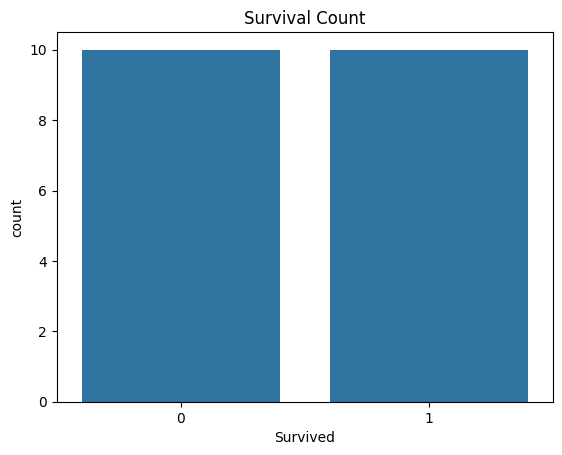

In [12]:
sns.countplot(x="Survived", data=data)

plt.title("Survival Count")

plt.show()

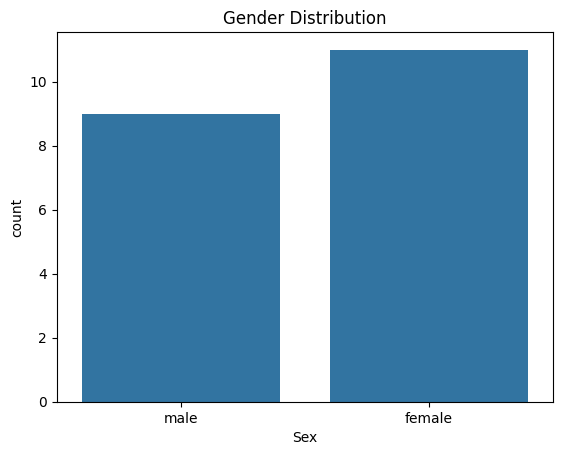

In [13]:
sns.countplot(x="Sex", data=data)

plt.title("Gender Distribution")

plt.show()

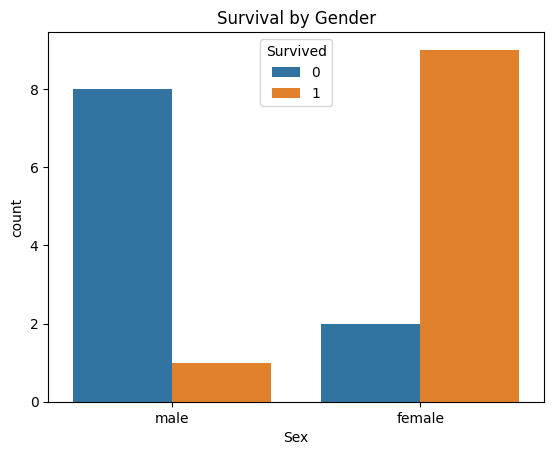

In [14]:
sns.countplot(x="Sex", hue="Survived", data=data)

plt.title("Survival by Gender")

plt.show()

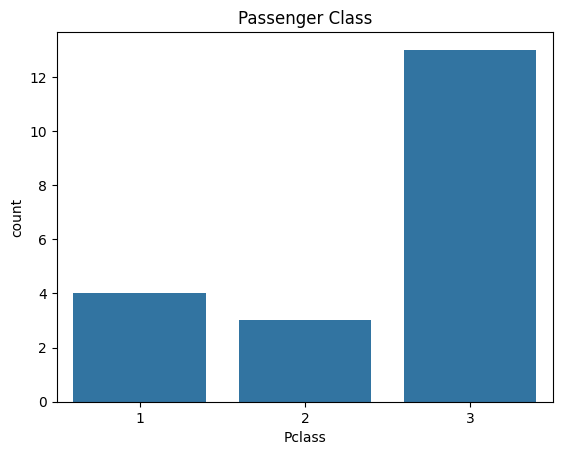

In [15]:
sns.countplot(x="Pclass", data=data)

plt.title("Passenger Class")

plt.show()

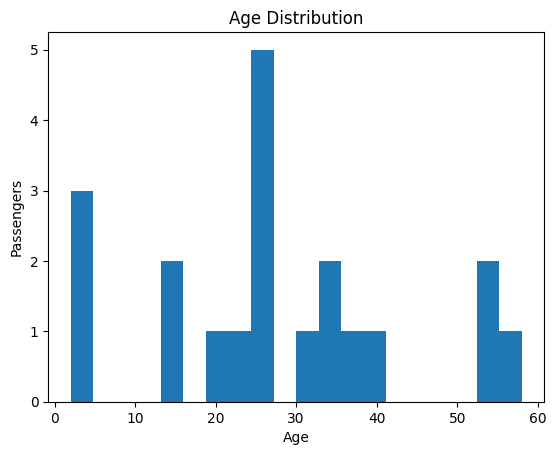

In [16]:
plt.hist(data["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Passengers")

plt.show()

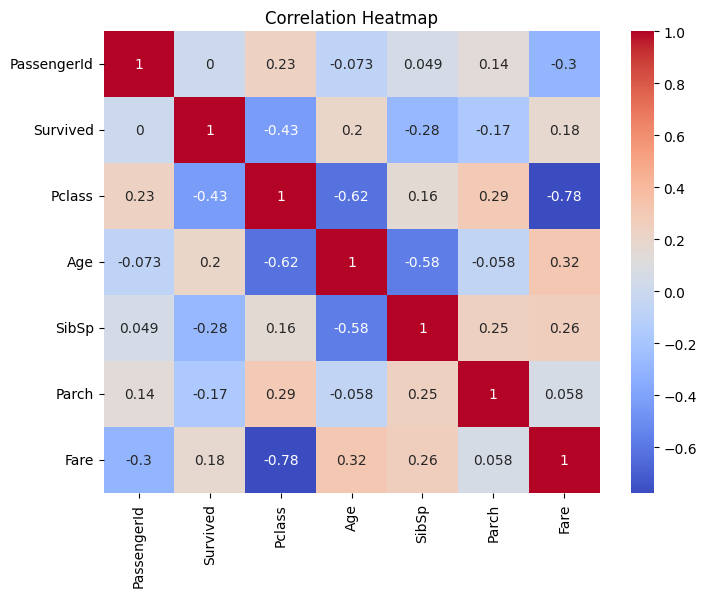

In [17]:
numeric_data = data.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [18]:
print("Total Passengers :", len(data))

print("Survival Rate :", data["Survived"].mean()*100)

print("Average Age :", data["Age"].mean())

print("Male Passengers :", (data["Sex"]=="male").sum())

print("Female Passengers :", (data["Sex"]=="female").sum())

Total Passengers : 20
Survival Rate : 50.0
Average Age : 27.85
Male Passengers : 9
Female Passengers : 11
